# Custom inventory policies: from a familiar rule to a tuned extension

This tutorial implements a small reorder rule as a `BasePolicy` subclass, tests its decisions, tunes one parameter against declared costs, and makes one controlled change to the rule. The policy requests orders; Stockcast owns demand processing, lead-time transitions, inventory mutation, and canonical events.

The starting rule is the familiar **(s,Q) reorder point policy**: when inventory position is at or below threshold `s`, request a fixed quantity `Q`. Inventory position is **on-hand + pipeline − backorders**, so stock already on its way matters.

Stockcast's built-in `ReorderPointPolicy(policy_type='sQ')` can express this rule. We write it ourselves here to show the extension contract and make its choices inspectable. The threshold and quantity are declared inputs; Stockcast does not infer them from demand or manufacture a forecast target. Later, we will tune `Q` against explicit costs and extend the request formula. For ordinary `(s,Q)` use, the built-in policy is the simpler choice.

In [2]:
import math

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from stockcast import (
    BasePolicy, InventoryStateDataFrame, OrderDecision, SimulationEngine,
)
from stockcast.evaluation import (
    InventoryEvaluator, avg_on_hand, demand_period_service_level,
    fill_rate, order_units,
)

## 1. Define the policy contract

A custom policy inherits operating settings from `BasePolicy`: lead time, decision schedule, shortage mode, and optional service probability. Here `__init__` validates the declared parameters, and `fit()` marks the policy ready; there is no forecast table to estimate. The engine calls `predict()` only at scheduled opportunities.

`predict()` reads inventory state and returns an `OrderDecision`. That object carries the requested quantity, the position used to decide, and order/delivery periods. It does not place the order or edit on-hand stock; the engine handles acceptance, timing, and physical state.

In [3]:
class ReorderWhenBelowPolicy(BasePolicy):
    """Request a fixed quantity when inventory position reaches a threshold."""

    def __init__(
        self, reorder_threshold, order_quantity, parameter_source, **kwargs,
    ):
        # BasePolicy validates lead time, review schedule, and shortage mode.
        super().__init__(**kwargs)
        # Fail early before an invalid operating input reaches the engine.
        self.reorder_threshold = float(reorder_threshold)
        self.order_quantity = float(order_quantity)
        if not math.isfinite(self.reorder_threshold) or self.reorder_threshold < 0:
            raise ValueError('reorder_threshold must be finite and non-negative')
        if not math.isfinite(self.order_quantity) or self.order_quantity <= 0:
            raise ValueError('order_quantity must be finite and positive')
        if not isinstance(parameter_source, str) or not parameter_source.strip():
            raise ValueError('parameter_source must be a non-empty string')
        self.parameter_source = parameter_source.strip()

    def fit(self, forecast_df=None, **kwargs):
        # The parameters were checked in __init__; no forecast is fitted here.
        # The engine rejects a policy until this flag is set.
        self.fitted_ = True
        return self

    def predict(self, inventory_state_df, current_period=0, **kwargs):
        if not self.fitted_:
            raise ValueError('policy must be fitted before prediction')

        # Use on-hand + in-transit - backorders, so outstanding stock counts.
        # Work on a new table; predict() must leave the supplied state untouched.
        positions = inventory_state_df.inventory_position()
        sku_column = inventory_state_df.sku_column
        decision = positions[[sku_column, 'inventory_position']].copy()
        # Each SKU requests Q at or below s and zero above s.
        decision['order_quantity'] = (
            decision['inventory_position'].le(self.reorder_threshold).astype(float)
            * self.order_quantity
        )
        # This is a fixed-quantity rule, so an order-up-to target is not applicable.
        decision['target_level'] = math.nan
        decision['reorder_point'] = self.reorder_threshold
        # The engine interprets these zero-based demand-period coordinates.
        decision['order_period'] = current_period
        decision['expected_delivery_period'] = current_period + self.lead_time
        # Return a request, not a mutation of stock or pipeline.
        return OrderDecision(
            decision[[
                sku_column, 'order_quantity', 'target_level',
                'inventory_position', 'reorder_point', 'order_period',
                'expected_delivery_period',
            ]],
            sku_column=sku_column,
            lead_time=self.lead_time,
            review_period=self.review_period,
        )


## 2. Declare the scenario

`review_period=1` creates a daily `PeriodicSchedule`, including an opportunity before the first demand row. `initial_decision="none"` is the neutral compatibility setting; it does not cancel that opportunity. `lead_time=2` makes accepted orders usable before demand two periods later. With `allow_backorders=False`, unmet demand becomes lost sales.

Opening stock equals the threshold, making the first positive decision easy to inspect. The short repeating demand path then lets the threshold be crossed again after receipts and consumption. These values make the mechanics visible; they are not calibrated recommendations.

In [4]:
sku = 'widget_A'
opening_date = pd.Timestamp('2026-03-01')
period_frequency = 'D'
lead_time = 2
review_period = 1
reorder_threshold = 6.0
fixed_order_quantity = 10.0
initial_decision = 'none'
demand_source_name = 'declared_custom_policy_scenario'
random_seed = None


In [5]:
# No forecast quantile is used, so there is no target probability.
# fit() marks this validated, declared-parameter policy ready for the engine.
policy = ReorderWhenBelowPolicy(
    reorder_threshold=reorder_threshold,
    order_quantity=fixed_order_quantity,
    parameter_source='declared_scenario_input',
    lead_time=lead_time,
    review_period=review_period,
    service_level=None,
    allow_backorders=False,
).fit()

configuration = pd.DataFrame([{
    'policy': policy.policy_name,
    'fitted': policy.fitted_,
    'reorder_threshold': reorder_threshold,
    'order_quantity': fixed_order_quantity,
    'parameter_source': policy.parameter_source,
    'lead_time': lead_time,
    'review_period': review_period,
    'initial_decision': initial_decision,
    'allow_backorders': policy.allow_backorders,
}])
print(configuration.to_string(index=False))


                policy  fitted  reorder_threshold  order_quantity        parameter_source  lead_time  review_period initial_decision  allow_backorders
ReorderWhenBelowPolicy    True                6.0            10.0 declared_scenario_input          2              1             none             False


In [6]:
# Opening stock equals the threshold, making the first decision easy to inspect.
opening_stock = pd.DataFrame({
    'unique_id': [sku],
    'observed_on_hand': [6.0],
})
opening_stock


,unique_id,observed_on_hand
0,widget_A,6.0


In [7]:
# Initialize physical stock at the opening date; no stock or pipeline is inferred.
# max_lead_time allocates the two delivery slots the engine may need.
# The engine copies this caller-owned starting state for a run.
opening_inventory = InventoryStateDataFrame(
    [sku], max_lead_time=lead_time, allow_backorders=False,
).initialize_from_observed(
    opening_stock,
    on_hand_column='observed_on_hand',
    start_date=opening_date,
)
opening_inventory


InventoryStateDataFrame(n_skus=1, total_on_hand=6, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

In [8]:
opening_view = opening_inventory.inventory_position()
print('Opening state')
print(opening_view[[
    'unique_id', 'date', 'period', 'on_hand', 'backorders',
    'total_in_transit', 'inventory_position',
]].to_string(index=False))


Opening state
unique_id       date  period  on_hand  backorders  total_in_transit  inventory_position
 widget_A 2026-03-01     0.0      6.0         0.0               0.0                 6.0


In [9]:
demand_values = [2.0, 3.0, 4.0, 2.0, 3.0, 4.0, 2.0, 3.0, 4.0, 2.0]
# demand period 0 is the day after opening; dates advance at frequency D.
# The engine requires one dated row per SKU and demand period.
demand = pd.DataFrame({
    'unique_id': [sku] * len(demand_values),
    'period': range(len(demand_values)),
    'date': pd.date_range(
        opening_date + pd.Timedelta(days=1),
        periods=len(demand_values),
        freq=period_frequency,
    ),
    'y': demand_values,
})


In [10]:
# Ten dated rows begin the day after the opening state; the short repeating
# path lets the threshold trigger several review decisions in view.
assert len(demand) == len(demand_values)
assert demand[['unique_id', 'period']].duplicated().sum() == 0
assert demand['date'].min() == opening_date + pd.Timedelta(days=1)

print('Declared demand')
print(demand.to_string(index=False))


Declared demand
unique_id  period       date   y
 widget_A       0 2026-03-02 2.0
 widget_A       1 2026-03-03 3.0
 widget_A       2 2026-03-04 4.0
 widget_A       3 2026-03-05 2.0
 widget_A       4 2026-03-06 3.0
 widget_A       5 2026-03-07 4.0
 widget_A       6 2026-03-08 2.0
 widget_A       7 2026-03-09 3.0
 widget_A       8 2026-03-10 4.0
 widget_A       9 2026-03-11 2.0


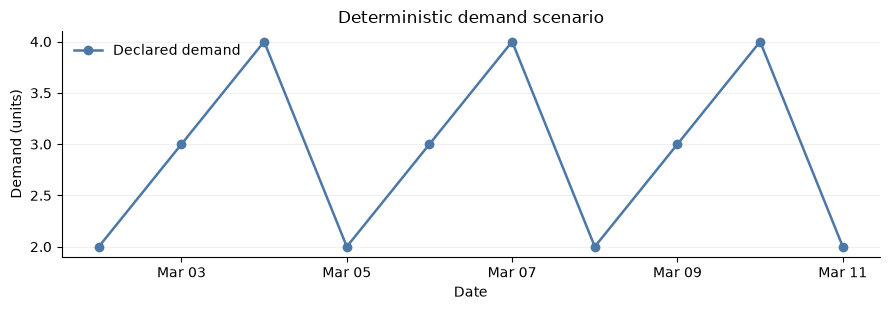

In [11]:
# Plot the repeating path before the policy ever sees it.
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(demand['date'], demand['y'], marker='o', linewidth=1.8, color='#4C78A8',
        label='Declared demand')
ax.set(title='Deterministic demand scenario', xlabel='Date', ylabel='Demand (units)')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


## 3. Inspect one decision

Opening inventory position equals the threshold, so the policy requests 10 units. The decision table keeps the state used by the rule (`inventory_position`), its trigger (`reorder_point`), the requested quantity, and delivery timing together.

The expected delivery period is the order period plus the two-day lead time. `target_level` is intentionally empty because this policy requests a fixed quantity rather than ordering up to a target.

In [12]:
# Compare defensive copies before and after predict() to show read-only behavior.
state_before_prediction = opening_inventory.get_dataframe()
opening_decision = policy.predict(opening_inventory, current_period=0)
state_after_prediction = opening_inventory.get_dataframe()

print('Order decision')
print(opening_decision.get_dataframe().to_string(index=False))
print(f'\nInventory unchanged by predict(): {state_before_prediction.equals(state_after_prediction)}')

assert state_before_prediction.equals(state_after_prediction)


Order decision
unique_id  order_quantity  target_level  inventory_position  reorder_point  order_period  expected_delivery_period
 widget_A            10.0           NaN                 6.0            6.0             0                         2

Inventory unchanged by predict(): True


## 4. Let the engine run the policy

`SimulationEngine.run` copies the caller's inventory and policy. At each daily opportunity it uses the fitted rule before that day's demand; accepted orders enter the pipeline and arrive according to `lead_time`. The result carries both final state and canonical event rows. We pass the complete dated demand path and name its source so the replay is reproducible.

All ten periods are scoring periods here. There is no warm-up or settlement tail because the example focuses only on the custom decision path.

In [13]:
# Scoring covers all ten demand rows. No demand is generated inside the engine.
# With a fixed path, random_seed=None explicitly records that no draw is needed.
result = SimulationEngine().run(
    policy=policy,
    demand_source=demand,
    inventory=opening_inventory,
    n_periods=len(demand),
    period_frequency=period_frequency,
    initial_decision=initial_decision,
    warmup_periods=0,
    scoring_periods=len(demand),
    settlement_periods=0,
    order_during_settlement=False,
    demand_source_name=demand_source_name,
    random_seed=random_seed,
)

In [14]:
# The engine owns this state; the caller-owned `opening_inventory` above is unchanged.
result.inventory


InventoryStateDataFrame(n_skus=1, total_on_hand=0, total_safety_stock=0, total_backorders=0, has_stockout=True, has_backorder=False)

The period-0 event shows that ordering 10 units leaves physical on-hand at 6 while pipeline stock becomes 10. Physical stock changes only when that order is received two periods later.

`result.to_event_frame(window="all")` exposes the period ledger. Its `decision_inventory_position` is the state the policy read before that day's order. With no constraints or callbacks here, accepted `order_quantity` equals the request. Receipts, lost sales, and ending stock come from the engine, so we can check the rule and its physical consequences from one table.

In [15]:
# One canonical row per SKU and demand period in this scenario.
events = result.to_event_frame(window='all')
opening_event = events.loc[events['demand_period'].eq(0)].copy()
period_events = events.loc[events['event_type'].eq('period')].copy()
# With no callbacks or constraints, the accepted quantity is the policy request.
period_events['pre_order_inventory_position'] = period_events['decision_inventory_position']
period_events['rule_triggered'] = (
    period_events['pre_order_inventory_position'] <= reorder_threshold
)

print(f"Engine events: {len(events)} rows (ten demand periods including the first decision)")
print('\nFirst demand epoch and its pre-demand order')
print(opening_event[[
    'event_type', 'date', 'order_quantity', 'ending_on_hand', 'on_order_end',
]].to_string(index=False))


Engine events: 10 rows (ten demand periods including the first decision)

First demand epoch and its pre-demand order
event_type       date  order_quantity  ending_on_hand  on_order_end
    period 2026-03-02            10.0             4.0          10.0


In [16]:
print('Period event evidence')
print(period_events[[
    'date', 'demand', 'pre_order_inventory_position', 'rule_triggered',
    'order_quantity', 'received_units', 'ending_on_hand', 'on_order_end',
    'shortage_units',
]].to_string(index=False, float_format=lambda value: f"{value:.3f}"))


Period event evidence
      date  demand  pre_order_inventory_position  rule_triggered  order_quantity  received_units  ending_on_hand  on_order_end  shortage_units
2026-03-02   2.000                         6.000            True          10.000           0.000           4.000        10.000           0.000
2026-03-03   3.000                        14.000           False           0.000           0.000           1.000        10.000           0.000
2026-03-04   4.000                        11.000           False           0.000          10.000           7.000         0.000           0.000
2026-03-05   2.000                         7.000           False           0.000           0.000           5.000         0.000           0.000
2026-03-06   3.000                         5.000            True          10.000           0.000           2.000        10.000           0.000
2026-03-07   4.000                        12.000           False           0.000           0.000           0.000        

In [17]:
# fit() selects the scoring event window and validates it.
# evaluate() computes named metrics from those event rows, not policy internals.
metrics = InventoryEvaluator().fit(
    simulation_result=result, window='scoring',
).evaluate(
    metrics=[fill_rate, demand_period_service_level, avg_on_hand, order_units],
    groupby=[],  # Pool this one-SKU scenario into one result row.
)
print('Scoring-window metrics')
print(metrics.round(3).to_string(index=False))

# The engine manifest records shared policy settings; keep the custom s/Q
# values and their declared source alongside it as reproducible scenario inputs.
manifest_policy = result.run_manifest['policy']
manifest_view = pd.DataFrame([{
    'class': manifest_policy['class'],
    'lead_time': manifest_policy['lead_time'],
    'review_period': manifest_policy['review_period'],
    'service_level': manifest_policy['service_level'],
    'allow_backorders': manifest_policy['allow_backorders'],
}])
print('\nEngine manifest policy settings')
print(manifest_view.to_string(index=False))
print('\nCustom inputs kept as explicit scenario evidence')
print(configuration[[
    'reorder_threshold', 'order_quantity', 'parameter_source',
]].to_string(index=False))

Scoring-window metrics
 fill_rate  demand_period_service_level  avg_on_hand  order_units
     0.897                          0.8          3.3         30.0

Engine manifest policy settings


                 class  lead_time  review_period service_level  allow_backorders
ReorderWhenBelowPolicy          2              1          None             False

Custom inputs kept as explicit scenario evidence
 reorder_threshold  order_quantity        parameter_source
               6.0            10.0 declared_scenario_input


## 5. See the rule and its inventory consequences

The first panel checks the decision rule: red markers occur only where pre-order inventory position reaches or falls below the dashed threshold. The second panel separates requests from receipts, making the two-period delay visible. The third distinguishes usable on-hand stock from units still in transit.

The first order is placed before the first demand. It enters the pipeline and arrives before demand two epochs later. Both order and receipt markers belong to ordinary period events.

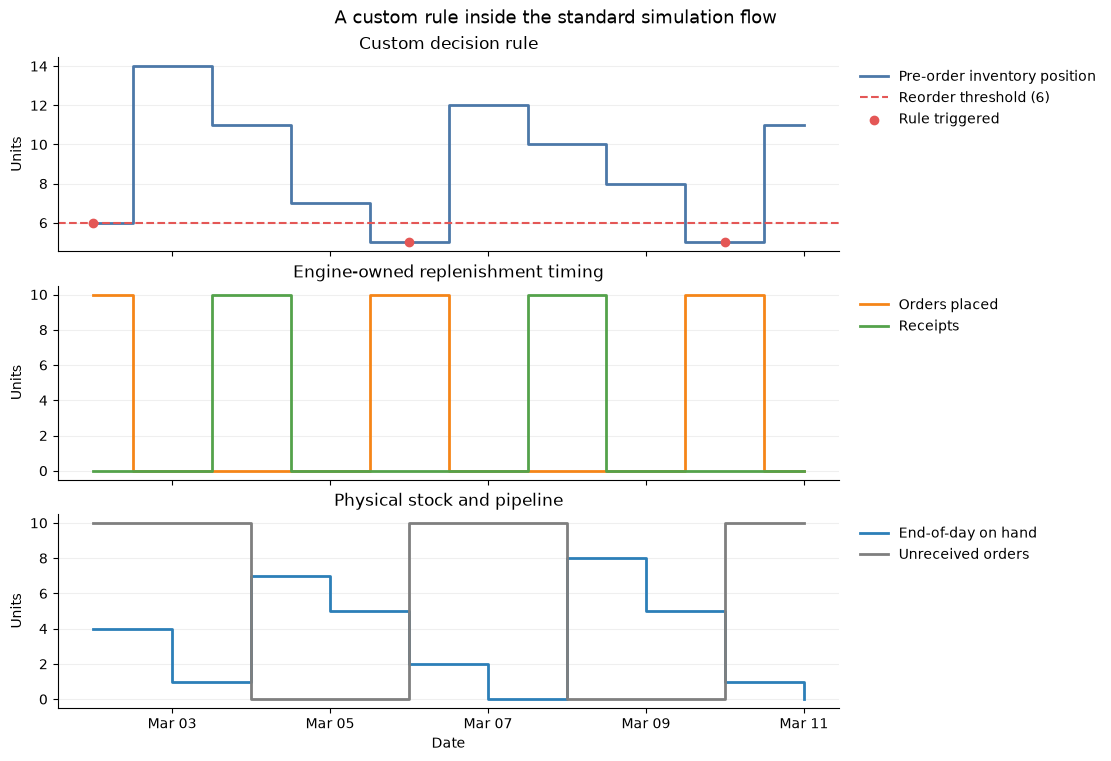

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True, layout='constrained')

# Step lines suit values that remain in effect over discrete inventory periods.
axes[0].step(
    period_events['date'], period_events['pre_order_inventory_position'],
    where='mid', linewidth=2, color='#4C78A8', label='Pre-order inventory position',
)
axes[0].axhline(
    reorder_threshold, color='#E45756', linestyle='--',
    label=f'Reorder threshold ({reorder_threshold:g})',
)
triggered = period_events.loc[period_events['rule_triggered']]
axes[0].scatter(
    triggered['date'], triggered['pre_order_inventory_position'],
    color='#E45756', zorder=3, label='Rule triggered',
)
axes[0].set(title='Custom decision rule', ylabel='Units')

axes[1].step(
    period_events['date'], period_events['order_quantity'], where='mid',
    linewidth=2, color='#F58518', label='Orders placed',
)
axes[1].step(
    period_events['date'], period_events['received_units'], where='mid',
    linewidth=2, color='#54A24B', label='Receipts',
)
axes[1].set(title='Engine-owned replenishment timing', ylabel='Units')

axes[2].step(
    period_events['date'], period_events['ending_on_hand'], where='post',
    linewidth=2, color='#2C7FB8', label='End-of-day on hand',
)
axes[2].step(
    period_events['date'], period_events['on_order_end'], where='post',
    linewidth=2, color='#7F7F7F', label='Unreceived orders',
)
axes[2].set(title='Physical stock and pipeline', xlabel='Date', ylabel='Units')
axes[2].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

for ax in axes:
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))
    ax.grid(axis='y', alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('A custom rule inside the standard simulation flow', fontsize=13)
plt.show()

## 6. Tune the fixed quantity against declared costs

`Q` trades off order frequency, stock held, and unmet demand. **Ordering cost alone is not the objective**: placing no orders would minimize it. For this exercise, `total_cost` adds a fixed cost per positive SKU order line, a cost for each unit held at day end, and a cost for each unit of lost sales. These are illustrative business assumptions, not estimated facts. We keep `s`, lead time, opening stock, and shortage mode fixed.

We compare a small, declared grid of `Q` values on a 28-day **calibration** path. A separate, later 14-day path is declared for transparency but is not used to select `Q`. Each path is an independent replay from the same opening stock, rather than a continuation of the other. We also report terminal pipeline stock: it is visible in the results but is not charged by this chosen cost objective.

In [19]:
from stockcast.evaluation import (
    holding_cost, ordering_cost, shortage_cost, sku_order_line_count,
    terminal_pipeline_units, total_cost, validate_event_frame,
)

candidate_quantities = [6, 8, 10, 12, 16, 20]
calibration_values = [2, 3, 4, 2, 3, 4, 3] * 4
held_out_values = [5, 3, 5, 2, 4, 3, 5, 3, 4, 2, 5, 3, 4, 3]
# Costs are evaluator inputs, not parameters that the policy optimizes itself.
cost_context = {
    'cost_components': ['ordering', 'holding', 'shortage'],
    'order_cost_per_sku_line': 5.0,
    'order_cost_per_unit': 0.0,  # Explicit zero: no variable ordering fee.
    'holding_cost_per_unit_period': 0.50,
    'shortage_cost_per_unit': 8.0,
}

def dated_demand(values, first_date):
    # Build the complete SKU/date/period grid expected by run_comparison.
    return pd.DataFrame({
        'unique_id': [sku] * len(values),
        'period': range(len(values)),
        'date': pd.date_range(first_date, periods=len(values), freq=period_frequency),
        'y': values,
    })

def fresh_opening(first_date):
    # Start each comparison from the same stock, with dates aligned to demand.
    return InventoryStateDataFrame(
        [sku], max_lead_time=lead_time, allow_backorders=False,
    ).initialize_from_observed(
        opening_stock, on_hand_column='observed_on_hand',
        start_date=first_date - pd.Timedelta(days=1),
    )

def fitted_rule(quantity, rule_class=ReorderWhenBelowPolicy, **extra):
    # Only Q or the named class extension changes; all other settings stay fixed.
    return rule_class(
        reorder_threshold=reorder_threshold, order_quantity=quantity,
        parameter_source='declared_tuning_grid', lead_time=lead_time,
        review_period=review_period, service_level=None,
        allow_backorders=False, **extra,
    ).fit()

calibration_demand = dated_demand(calibration_values, pd.Timestamp('2026-04-01'))
held_out_demand = dated_demand(held_out_values, pd.Timestamp('2026-04-29'))
print('Cost assumptions:', cost_context)
print('Calibration:', calibration_demand.date.min().date(), 'to', calibration_demand.date.max().date())
print('Held out:', held_out_demand.date.min().date(), 'to', held_out_demand.date.max().date())

Cost assumptions: {'cost_components': ['ordering', 'holding', 'shortage'], 'order_cost_per_sku_line': 5.0, 'order_cost_per_unit': 0.0, 'holding_cost_per_unit_period': 0.5, 'shortage_cost_per_unit': 8.0}
Calibration: 2026-04-01 to 2026-04-28
Held out: 2026-04-29 to 2026-05-12


`SimulationEngine.run_comparison` gives every candidate the same complete calibration demand and an isolated copy of the same opening inventory. Its `results` mapping lets us evaluate each branch separately. `InventoryEvaluator.fit(..., window="scoring")` validates and selects those event rows; `evaluate(..., context=cost_context, groupby=[])` applies the same declared cost rates and returns one pooled result row. The fixed ordering charge counts **positive SKU order lines**, not a shared warehouse order fee.

In [20]:
# A separately fitted instance for each candidate keeps policy state isolated.
calibration_labels = [f'Q={quantity}' for quantity in candidate_quantities]
calibration_comparison = SimulationEngine().run_comparison(
    policies=[fitted_rule(quantity) for quantity in candidate_quantities],
    labels=calibration_labels, demand_source=calibration_demand,
    inventory=fresh_opening(calibration_demand.date.min()),
    n_periods=len(calibration_demand), period_frequency=period_frequency,
    initial_decision=initial_decision, warmup_periods=0,
    scoring_periods=len(calibration_demand), settlement_periods=0,
    order_during_settlement=False,
    demand_source_name='declared_calibration_demand', random_seed=None,
)

cost_metrics = [ordering_cost, holding_cost, shortage_cost, total_cost,
                sku_order_line_count, fill_rate, avg_on_hand, terminal_pipeline_units]
calibration_rows = []
for quantity, label in zip(candidate_quantities, calibration_labels):
    run = calibration_comparison.results[label]
    # Make the ledger check visible; InventoryEvaluator also validates it.
    validate_event_frame(run.to_event_frame(window='scoring'))
    row = InventoryEvaluator().fit(
        simulation_result=run, window='scoring',
    ).evaluate(metrics=cost_metrics, groupby=[], context=cost_context).iloc[0].to_dict()
    calibration_rows.append({'Q': quantity, **row})
calibration_scores = pd.DataFrame(calibration_rows).sort_values('Q').reset_index(drop=True)
assert (calibration_scores.total_cost - calibration_scores[
    ['ordering_cost', 'holding_cost', 'shortage_cost']
].sum(axis=1)).abs().lt(1e-9).all()
# Choose only within the displayed grid; ties go to the smaller Q.
selected_quantity = int(calibration_scores.sort_values(['total_cost', 'Q']).iloc[0].Q)
print(calibration_scores.round(2).to_string(index=False))
print(f'Lowest declared calibration cost in this grid: Q={selected_quantity}')

 Q  ordering_cost  holding_cost  shortage_cost  total_cost  sku_order_line_count  fill_rate  avg_on_hand  terminal_pipeline_units
 6           60.0          22.0           96.0       178.0                  12.0       0.86         1.57                      6.0
 8           50.0          33.5           56.0       139.5                  10.0       0.92         2.39                      8.0
10           40.0          45.5           88.0       173.5                   8.0       0.87         3.25                     10.0
12           35.0          57.5           64.0       156.5                   7.0       0.90         4.11                     12.0
16           25.0          86.5           56.0       167.5                   5.0       0.92         6.18                      0.0
20           20.0         112.5           16.0       148.5                   4.0       0.98         8.04                      0.0
Lowest declared calibration cost in this grid: Q=8


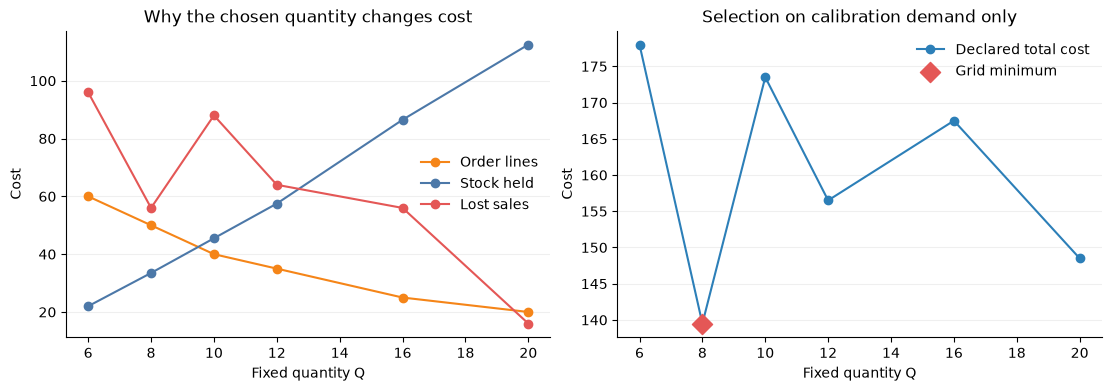

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout='constrained')
for column, label, color in [
    ('ordering_cost', 'Order lines', '#F58518'),
    ('holding_cost', 'Stock held', '#4C78A8'),
    ('shortage_cost', 'Lost sales', '#E45756'),
]:
    axes[0].plot(calibration_scores.Q, calibration_scores[column], marker='o',
                 label=label, color=color)
axes[0].set(title='Why the chosen quantity changes cost', xlabel='Fixed quantity Q', ylabel='Cost')
axes[0].legend(frameon=False)
axes[1].plot(calibration_scores.Q, calibration_scores.total_cost,
             marker='o', color='#2C7FB8', label='Declared total cost')
chosen = calibration_scores.loc[calibration_scores.Q.eq(selected_quantity)].iloc[0]
axes[1].scatter([chosen.Q], [chosen.total_cost], s=105, marker='D',
                color='#E45756', zorder=3, label='Grid minimum')
axes[1].set(title='Selection on calibration demand only', xlabel='Fixed quantity Q', ylabel='Cost')
axes[1].legend(frameon=False)
for ax in axes:
    ax.grid(axis='y', alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()

The minimum is **only the best candidate in this grid for this declared calibration path and cost context**. It is not a generally optimal `(s,Q)` policy. In particular, the threshold remains fixed, and short finite runs can be sensitive to ending stock and orders still in transit. The reported `terminal_pipeline_units` is a diagnostic, not a cost component here. We report those outcomes when we check the selected rule on new demand.

## 7. Make one small rule extension

Suppose a buyer wants a larger request when the inventory position has fallen far **below** `s`. We can retain the tested base rule and add one transparent response: on a triggered decision, request `Q + b × (s − inventory position)` when the gap is positive. Here `b=1` is a declared illustrative choice. At the threshold the gap is zero, so the original `Q` remains unchanged. Below it, the extra units grow with the gap. This is a custom variant, not a newly optimized policy; it introduces no forecast, hidden state, or change to engine timing.

In [22]:
class ShortfallResponsivePolicy(ReorderWhenBelowPolicy):
    """Add units in proportion to the gap below the reorder threshold."""

    def __init__(self, *, extra_per_unit_shortfall, **kwargs):
        super().__init__(**kwargs)
        self.extra_per_unit_shortfall = float(extra_per_unit_shortfall)
        if not math.isfinite(self.extra_per_unit_shortfall) or self.extra_per_unit_shortfall < 0:
            raise ValueError('extra_per_unit_shortfall must be finite and non-negative')

    def predict(self, inventory_state_df, current_period=0, **kwargs):
        # Reuse the parent's trigger, timing, and OrderDecision fields.
        base = super().predict(inventory_state_df, current_period=current_period, **kwargs)
        decision = base.get_dataframe()
        # Only positions below s add units; positions above s keep a zero order.
        gap = (self.reorder_threshold - decision['inventory_position']).clip(lower=0)
        decision['order_quantity'] += self.extra_per_unit_shortfall * gap
        return OrderDecision(
            decision, sku_column=inventory_state_df.sku_column,
            lead_time=self.lead_time, review_period=self.review_period,
        )

responsive = fitted_rule(
    selected_quantity, rule_class=ShortfallResponsivePolicy,
    extra_per_unit_shortfall=1.0,
)
low_stock = InventoryStateDataFrame(
    [sku], max_lead_time=lead_time, allow_backorders=False,
).initialize_from_observed(
    pd.DataFrame({'unique_id': [sku], 'observed_on_hand': [3.0]}),
    on_hand_column='observed_on_hand', start_date=opening_date,
)
# A position of 3 is three units below s=6: Q becomes Q+3 when b=1.
low_stock_before = low_stock.get_dataframe()
base_request = fitted_rule(selected_quantity).predict(low_stock, current_period=0).get_dataframe()
responsive_request = responsive.predict(low_stock, current_period=0).get_dataframe()
assert low_stock.get_dataframe().equals(low_stock_before)
assert responsive_request.order_quantity.iloc[0] == base_request.order_quantity.iloc[0] + 3
print(pd.DataFrame({
    'pre_order_position': [3.0], 'threshold': [reorder_threshold],
    'fixed_Q_request': [base_request.order_quantity.iloc[0]],
    'responsive_request': [responsive_request.order_quantity.iloc[0]],
}).to_string(index=False))

 pre_order_position  threshold  fixed_Q_request  responsive_request
                3.0        6.0              8.0                11.0


Finally, compare the originally declared `Q=10`, the calibration-selected fixed `Q`, and the illustrative responsive variant on the **same held-out demand**. All three start from the same stock, use the same schedule and lead time, and face the same costs. We fit one policy per branch and pass the same held-out table to `run_comparison`. The responsive rule did not participate in the calibration grid, so its result is descriptive rather than a tuned winner.

In [23]:
# The first branch is the original teaching rule; the other two use Q
# selected without consulting this later demand path.
held_out_policies = [
    fitted_rule(fixed_order_quantity),
    fitted_rule(selected_quantity),
    responsive,
]
held_out_labels = ['Original Q=10', f'Selected Q={selected_quantity}', 'Responsive variant']
held_out_comparison = SimulationEngine().run_comparison(
    policies=held_out_policies, labels=held_out_labels,
    demand_source=held_out_demand,
    inventory=fresh_opening(held_out_demand.date.min()),
    n_periods=len(held_out_demand), period_frequency=period_frequency,
    initial_decision=initial_decision, warmup_periods=0,
    scoring_periods=len(held_out_demand), settlement_periods=0,
    order_during_settlement=False,
    demand_source_name='declared_held_out_demand', random_seed=None,
)
held_out_rows = []
for label, run in held_out_comparison.results.items():
    validate_event_frame(run.to_event_frame(window='scoring'))
    row = InventoryEvaluator().fit(
        simulation_result=run, window='scoring',
    ).evaluate(metrics=cost_metrics, groupby=[], context=cost_context).iloc[0].to_dict()
    held_out_rows.append({'rule': label, **row})
held_out_scores = pd.DataFrame(held_out_rows)
print(held_out_scores.round(2).to_string(index=False))

              rule  ordering_cost  holding_cost  shortage_cost  total_cost  sku_order_line_count  fill_rate  avg_on_hand  terminal_pipeline_units
     Original Q=10           20.0          18.0           96.0       134.0                   4.0       0.76         2.57                      0.0
      Selected Q=8           25.0          11.0          104.0       140.0                   5.0       0.75         1.57                      8.0
Responsive variant           20.0          18.5           96.0       134.5                   4.0       0.76         2.64                      0.0


In [24]:
# Align the two ledgers by the shared SKU/date grid to show which actual
# accepted orders changed, beyond comparing aggregate cost and service.
fixed_events = held_out_comparison.results[held_out_labels[1]].to_event_frame(window='scoring')
responsive_events = held_out_comparison.results[held_out_labels[2]].to_event_frame(window='scoring')
assert fixed_events[['unique_id', 'date']].reset_index(drop=True).equals(
    responsive_events[['unique_id', 'date']].reset_index(drop=True)
)
changed_orders = pd.DataFrame({
    'date': fixed_events.date.to_numpy(),
    'fixed_Q_order': fixed_events.order_quantity.to_numpy(),
    'responsive_order': responsive_events.order_quantity.to_numpy(),
})
changed_orders = changed_orders.loc[
    changed_orders.fixed_Q_order.ne(changed_orders.responsive_order)
]
assert not changed_orders.empty
print('Held-out decisions changed by the shortfall response')
print(changed_orders.to_string(index=False))

Held-out decisions changed by the shortfall response
      date  fixed_Q_order  responsive_order
2026-05-02            8.0              11.0
2026-05-05            8.0               0.0
2026-05-06            0.0              11.0
2026-05-08            8.0               0.0
2026-05-10            0.0              10.0
2026-05-11            8.0               0.0


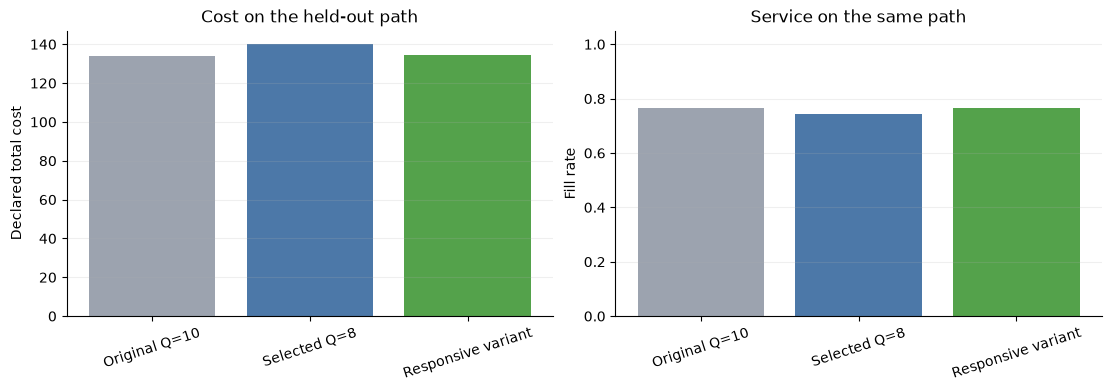

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout='constrained')
axes[0].bar(held_out_scores.rule, held_out_scores.total_cost, color=['#9CA3AF', '#4C78A8', '#54A24B'])
axes[0].set(title='Cost on the held-out path', ylabel='Declared total cost')
axes[1].bar(held_out_scores.rule, held_out_scores.fill_rate, color=['#9CA3AF', '#4C78A8', '#54A24B'])
axes[1].set(title='Service on the same path', ylabel='Fill rate', ylim=(0, 1.05))
for ax in axes:
    ax.tick_params(axis='x', rotation=18)
    ax.grid(axis='y', alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()

## Takeaway

The baseline rule is a familiar `(s,Q)` policy, also available as a built-in. Writing it as a `BasePolicy` subclass exposes the extension contract: validate declared inputs, fit explicitly, read inventory position, and return a timed `OrderDecision` without mutating stock. The engine still produces the physical flow and validated events.

The calibration grid selected `Q=8`, but on the later held-out path its declared cost was 140 versus 134 for the original `Q=10`. The responsive variant changed at least one order and cost 134.5 on that same path. This is a useful reminder to keep selection and evaluation separate: the result depends on the shown demand paths, costs, fixed threshold, and finite horizon. It establishes neither forecast calibration nor general policy optimality.